# Creating a DataLoader

Now we create a DataLoader from our processed dataset to make training easier

In [ ]:
# Folders
DATASET_URL = "https://drive.google.com/uc?export=download&id=1TyZmku25CZdeUd09He_Ddqcnm27OyyhS"
ROOT_DIR = "../data/PrunedBirdCLEF"

# Data
MAX_LENGTH = 60

### Downloading our data

We download our prunned dataset from the web

In [3]:
import gdown, os, zipfile

if not os.path.isdir(ROOT_DIR):
    os.mkdir(ROOT_DIR)
    gdown.download(DATASET_URL, f"{ROOT_DIR}/raw.zip", quiet=False)

    with zipfile.ZipFile(f"{ROOT_DIR}/raw.zip", 'r') as zip_ref:
        zip_ref.extractall(ROOT_DIR)

    os.remove(f"{ROOT_DIR}/raw.zip")



Downloading...
From (original): https://drive.google.com/uc?export=download&id=1TyZmku25CZdeUd09He_Ddqcnm27OyyhS
From (redirected): https://drive.google.com/uc?export=download&id=1TyZmku25CZdeUd09He_Ddqcnm27OyyhS&confirm=t&uuid=b1b59ea9-4487-4396-8f52-161a831fd33d
To: /home/moraguma/Documentos/git/Projeto-MO810-2025/src/gustavo/data/PrunedBirdCLEF/raw.zip
100%|██████████| 5.74G/5.74G [05:28<00:00, 17.5MB/s]


### Visualizing our data

We start by creating helper functions to allow the visualization of the collected data

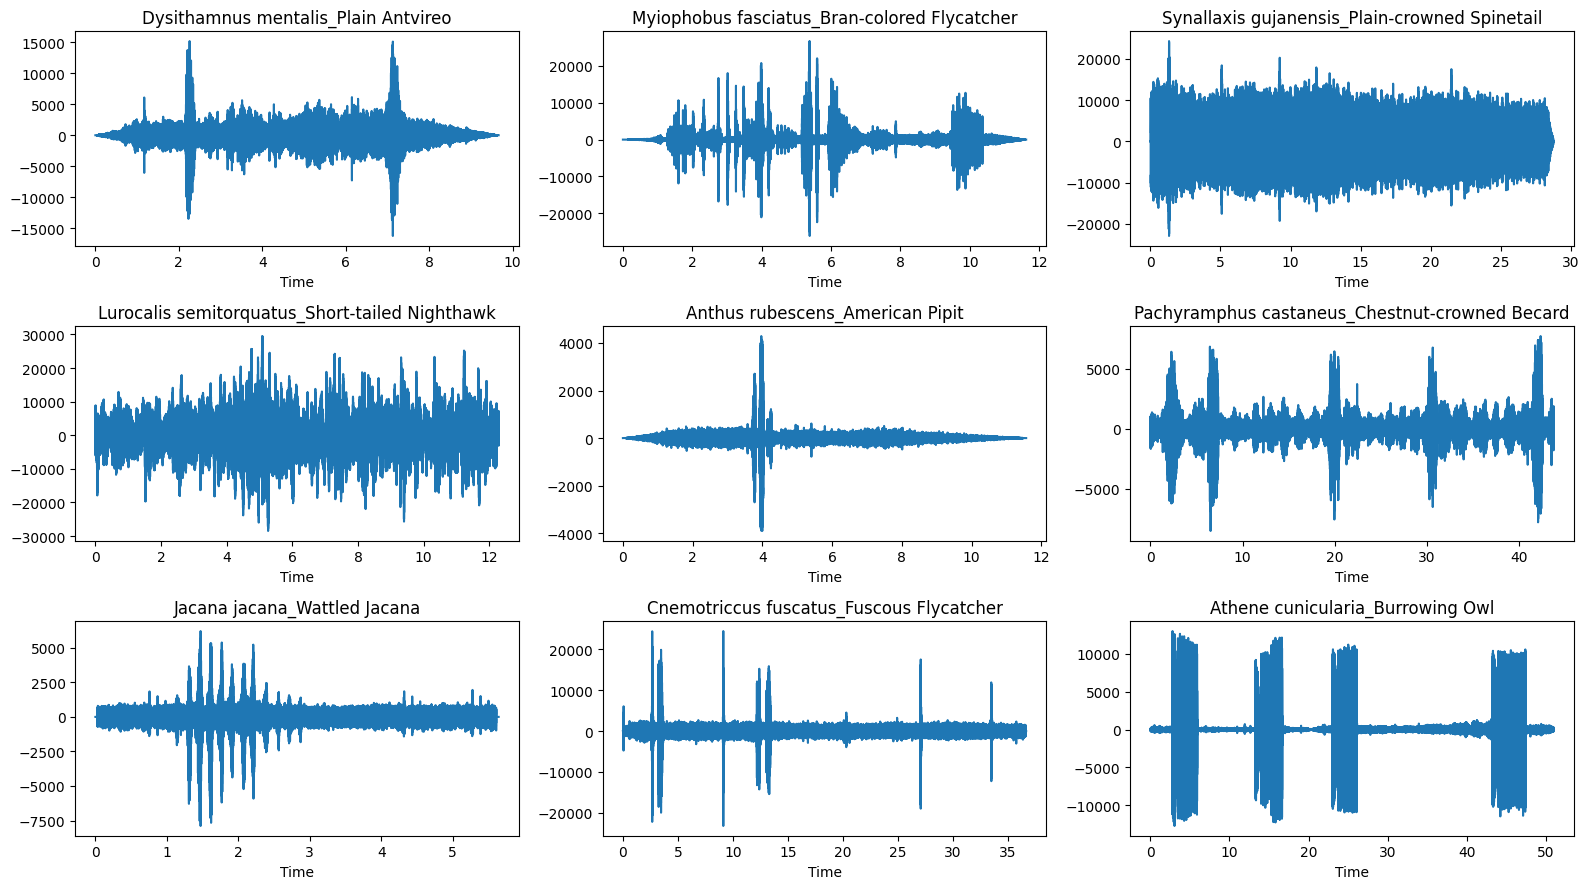

In [5]:
import random, json
from pydub import AudioSegment
import numpy as np
import matplotlib.pyplot as plt

def plot_waveform(ax, audio, label):
    """
    Plots the waveform of audio with the label on the given ax
    """
    waveform = np.array(audio.get_array_of_samples())

    time = np.linspace(
        0,
        len(waveform) / audio.frame_rate,
        num = len(waveform)
    )
    ax.set_title(label if not label is None else "Unlabeled")
    ax.set_xlabel("Time")
    ax.plot(time, waveform)


def get_sample(dataset_specs, split):
    """
    Returns the AudioSegment and label of a random sample from the given split of the dataset
    """

    idx = random.randint(0, len(dataset_specs[split]) - 1)
    path, label = dataset_specs[split][idx]
    path = f"{ROOT_DIR}/{path}"

    return AudioSegment.from_mp3(path), label


with open(f"{ROOT_DIR}/dataset_specs.json", "r") as f:
    dataset_specs = json.load(f)


fig, axes = plt.subplots(3, 3, figsize=(16, 9))

for i in range(3):
    for j in range(3):
        waveform, label = get_sample(dataset_specs, "train")
        label_name = dataset_specs["label_names"][str(label)] if str(label) in dataset_specs["label_names"] else None
        
        plot_waveform(axes[i, j], waveform, label_name)
plt.tight_layout()
plt.show()


### Creating the Dataset class

We override the Dataset class to load from our dataset

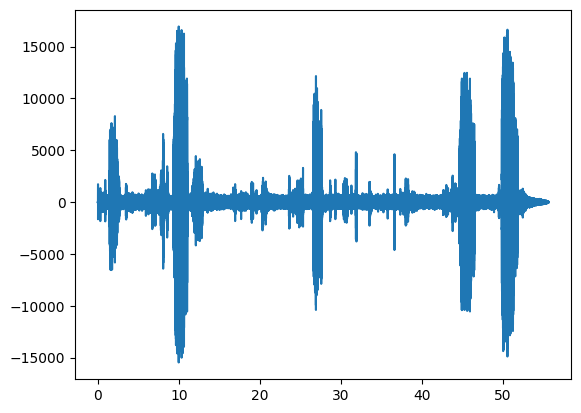

In [ ]:
import json
import torch
from torch import Tensor
import matplotlib.pyplot as plt
import numpy as np

with open(f"{ROOT_DIR}/dataset_specs.json") as f:
    dataset_specs = json.load(f)


audio, label = get_sample(dataset_specs, "train")
t = Tensor(audio.get_array_of_samples())


time = np.linspace(
    0,
    t.shape[0] / audio.frame_rate,
    t.shape[0]
)
plt.plot(time, t.numpy())
plt.show()

Waveform batch shape: torch.Size([8, 1, 2646000])
Labels batch shape: torch.Size([8])


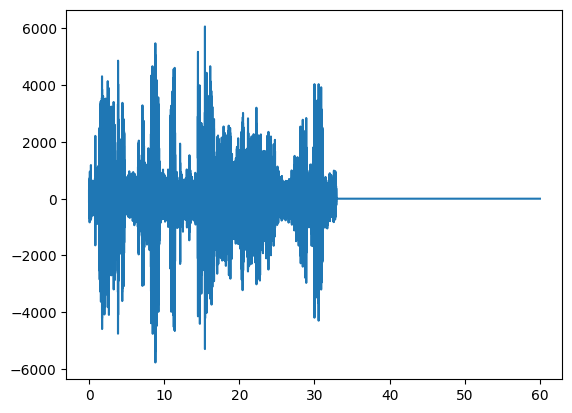

In [ ]:
import json
import torch
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from pydub import AudioSegment

import os, sys
sys.path.append(os.path.abspath("../../../"))

from api.MO810_API import MO810Dataset


class PrunedBirdCLEFDataset(MO810Dataset):
    """
    Our pruned BirdCLEF
    """

    def __init__(self, dataset_path, split, load_mode="disk", transform=None, *args, **kwargs):
        """
        Arguments:
            dataset_specs_path: String - Path to the dataset specs, which includes paths and labels
                to each sample as well as a label dictionary
            split: String - The split to be used. Either 'train', 'test' or 'unlabeled'
            load_mode: String - Either 'disk' or 'ram'. When 'disk', will load each sample from the
                disk as it is requested. When in 'ram', will load all samples into RAM on init
            transform: Callable, optional - Optional transform to be applied on a sample
        """
        super().__init__(*args, **kwargs)

        with open(f"{dataset_path}/dataset_specs.json", "r") as f:
            self.dataset_specs = json.load(f)

        self.dataset_path = dataset_path
        self.split = split
        self.load_mode = load_mode
        self.transform = transform
        # TODO - Add logic for loading in RAM
    

    def __len__(self):
        return len(self.dataset_specs[self.split])


    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.item()
        
        path, label = self.dataset_specs[self.split][idx]
        
        audio = AudioSegment.from_mp3(f"{self.dataset_path}/{path}")
        audio_tensor = Tensor(audio.get_array_of_samples())
        audio_tensor = F.pad(audio_tensor, (0, audio.frame_rate * MAX_LENGTH - audio_tensor.shape[0])).unsqueeze(0)

        return audio_tensor, label, audio.frame_rate

dataset = PrunedBirdCLEFDataset(
    ROOT_DIR, 
    split="train")
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)


waveforms, labels, frame_rates = next(iter(dataloader))
print(f"Waveform batch shape: {waveforms.shape}")
print(f"Labels batch shape: {labels.shape}")

time = np.linspace(
    0,
    waveforms[0].shape[1] / frame_rates[0],
    waveforms[0].shape[1]
)
plt.plot(time, waveforms[0, 0, :].numpy())
plt.xlabel = "Time"
plt.title = labels[0]
plt.show()